# Installation

In [ ]:
!pip install git+https://github.com/borongzhang/magpie_ptychography.git@main

# Imports

In [1]:
import numpy as np
import scipy.io
import matplotlib.pyplot as plt
import h5py
from numpy.fft import fft2, ifft2, fftshift, ifftshift
import imageio.v2 as imageio
import random
import time
from magpie_ptychography.src import magpie_loop, rpie, lbfgs
from magpie_ptychography.src import feasibility_distance_misfit
from magpie_ptychography.src import generate_intensity_measurements, generate_scanning_positions


# Setup

In [2]:
# Size of the object
object_shape = (512, 512)

# Side length of the probe
n_probe = 128



## Realistic Synthetic Object and Probe

In [4]:
mat_data = scipy.io.loadmat('assets/recon_zoneplate_Yi.mat')
obj = mat_data['obj']
orgn_probe = mat_data['probe']

pad_x = (object_shape[0] - obj.shape[0]) // 2
pad_y = (object_shape[1] - obj.shape[1]) // 2

# Pad the object to the desired shape
real_object = np.pad(obj, ((pad_x, pad_x), (pad_y, pad_y)), mode='edge')

ratio = orgn_probe.shape[0] // n_probe

real_probe = orgn_probe[::ratio,::ratio]

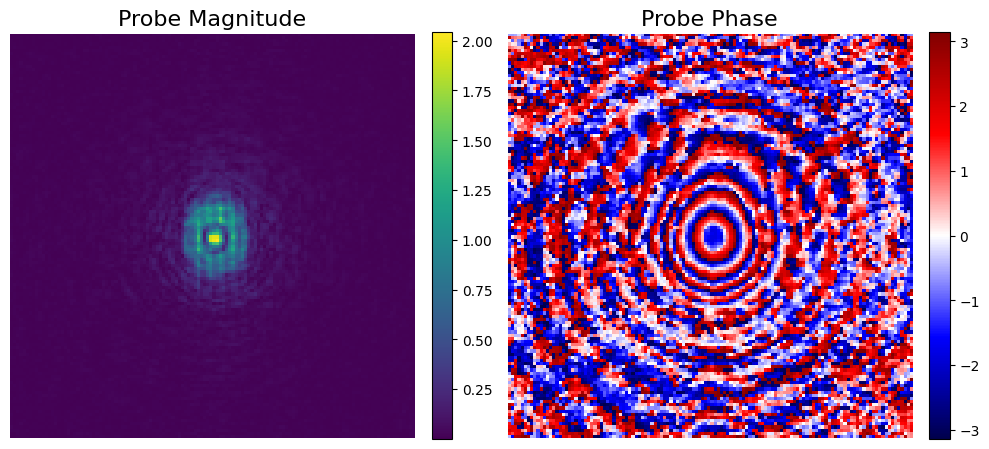

In [5]:
# Compute magnitude and phase
magnitude = np.abs(real_probe)
phase = np.angle(real_probe)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

ax = axes[0]
im0 = ax.imshow(magnitude, cmap='viridis')
ax.set_title('Probe Magnitude', fontsize = 16)
ax.axis('off')
plt.colorbar(im0, ax=ax, fraction=0.046, pad=0.04)

ax = axes[1]
im1 = ax.imshow(phase, cmap='seismic')
ax.set_title('Probe Phase', fontsize = 16)
ax.axis('off')
plt.colorbar(im1, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
#plt.savefig('probe_mag_phase.png', dpi=120, bbox_inches='tight')
plt.show()

## Test Synthetic Object 

In [7]:
# Load the images
baboon_image = imageio.imread('assets/baboon.tiff')
# Convert the Baboon image to grayscale 
if baboon_image.ndim == 3:
    baboon_image = np.mean(baboon_image, axis=2)
    
cameraman_image = imageio.imread('assets/cameraman.tif')
if cameraman_image.ndim == 3:
    cameraman_image = np.mean(cameraman_image, axis=2)

# Normalize the Baboon image to [0, 1] for magnitude
baboon_magnitude = baboon_image / np.max(baboon_image)

# Normalize the Cameraman image to [0, pi/2] for phase
cameraman_phase = (cameraman_image / np.max(cameraman_image)) * (np.pi / 2)

synthetic_object = baboon_magnitude * np.exp(1j * cameraman_phase)


/var/folders/26/rw2jcprn5qv45z71fxbk4t2w0000gn/T/ipykernel_79930/3075504364.py:15: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  cameraman_phase = (cameraman_image / np.max(cameraman_image)) * (np.pi / 2)
/var/folders/26/rw2jcprn5qv45z71fxbk4t2w0000gn/T/ipykernel_79930/3075504364.py:17: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  synthetic_object = baboon_magnitude * np.exp(1j * cameraman_phase)


/var/folders/26/rw2jcprn5qv45z71fxbk4t2w0000gn/T/ipykernel_79930/1642947703.py:1: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  magnitude = np.abs(synthetic_object)


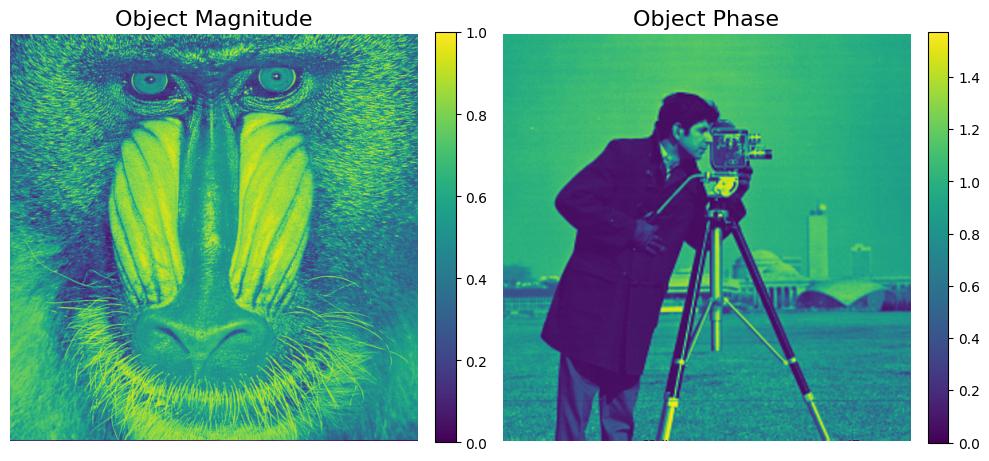

In [8]:
magnitude = np.abs(synthetic_object)
phase = np.angle(synthetic_object)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

ax = axes[0]
im0 = ax.imshow(magnitude, cmap='viridis')
ax.set_title('Object Magnitude', fontsize = 16)
ax.axis('off')
plt.colorbar(im0, ax=ax, fraction=0.046, pad=0.04)

ax = axes[1]
im1 = ax.imshow(phase, cmap='viridis')
ax.set_title('Object Phase', fontsize = 16)
ax.axis('off')
plt.colorbar(im1, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
#plt.savefig('synthetic_object.png', dpi=120, bbox_inches='tight')
plt.show()


## Data Generation

In [10]:
# Choose Object
probe = real_probe
ground_truth = synthetic_object

# Probe shift for intensity measurement
shift = 64

# Noise added to the measurement
noise_level = 0.05

# Define scanning positions
pos_array = generate_scanning_positions(object_shape, n_probe, shift)

# Generate the data
data = generate_intensity_measurements(ground_truth, probe, pos_array, noise_level)


# Numerical examples

In [20]:
misfit = feasibility_distance_misfit
z_initial = np.ones_like(ground_truth)
num_iterations = 1000
alpha_rpie = 0.01
print('The maximum level for MAGPIE is:', int(np.log2(probe.shape[0])))


The maximum level for MAGPIE is: 7


In [15]:
s = time.time()
z_recon_rPIE, res_rPIE, errors_rPIE = rpie(z_initial, probe, data, pos_array, 
                                                num_iterations, misfit, ground_truth,
                                                alpha = alpha_rpie, metric = True, tol = 1e-4)
print(time.time()-s)


Iteration: 0, f: 1649.2686773285577, g: 0.059520670217093286, error: 242.3473661616205
Iteration: 1, f: 74.96515308172718, g: 0.005215962325508104, error: 213.37725503537317
Iteration: 2, f: 38.81879486938311, g: 0.0019095931013412583, error: 204.56787840399846
Iteration: 3, f: 28.708632469853733, g: 0.0011401844370579244, error: 198.5522324190753
Iteration: 4, f: 23.404067964118134, g: 0.0008266345218280791, error: 193.75882806565437
Iteration: 5, f: 19.967656039246116, g: 0.0006607064168159374, error: 189.70606226333643
Iteration: 6, f: 17.501302549949664, g: 0.000560299640227918, error: 186.1658244768292
Iteration: 7, f: 15.622228676210598, g: 0.0004898602149943998, error: 183.00980687249597
Iteration: 8, f: 14.131989681313504, g: 0.0004449516957518967, error: 180.15666858785497
Iteration: 9, f: 12.915976669729138, g: 0.0004075627289801975, error: 177.54822225240326
Iteration: 10, f: 11.901403605162384, g: 0.00038017325773910115, error: 175.14285690346986
Iteration: 11, f: 11.040851

Iteration: 92, f: 1.6396677548421703, g: 0.00014030328044345743, error: 115.48065048303127
Iteration: 93, f: 1.6228384109106977, g: 0.00013784717659511038, error: 115.18426989016024
Iteration: 94, f: 1.6067174621135873, g: 0.00013819779624801826, error: 114.8909447746745
Iteration: 95, f: 1.59074832294692, g: 0.0001370548879805218, error: 114.6010056803641
Iteration: 96, f: 1.5751847946811903, g: 0.00013544410701513943, error: 114.31472265903395
Iteration: 97, f: 1.5600837807715635, g: 0.0001362984041240422, error: 114.0311824115256
Iteration: 98, f: 1.5450589691822976, g: 0.00013509925281253226, error: 113.75128876607542
Iteration: 99, f: 1.530437704708955, g: 0.00013375218896578082, error: 113.47445496447368
Iteration: 100, f: 1.5160873811884288, g: 0.00013325164104700747, error: 113.20083266682094
Iteration: 101, f: 1.5020502956982458, g: 0.0001323765177617222, error: 112.93028623350159
Iteration: 102, f: 1.4882475424975008, g: 0.00013113354759473151, error: 112.66250924575408
Itera

Iteration: 182, f: 0.878507268600622, g: 0.00010646607930374641, error: 97.52977330797754
Iteration: 183, f: 0.8742033304195288, g: 0.00010565567184153526, error: 97.39335856751146
Iteration: 184, f: 0.870049621866125, g: 0.00010643703129729804, error: 97.25771082556149
Iteration: 185, f: 0.8659261545767024, g: 0.0001054834536652224, error: 97.12275075197954
Iteration: 186, f: 0.8617955724898901, g: 0.00010466339729614046, error: 96.98908816671228
Iteration: 187, f: 0.8577244299916535, g: 0.00010451967790885457, error: 96.85624555128115
Iteration: 188, f: 0.8537684743538276, g: 0.00010481678070615233, error: 96.72429146940226
Iteration: 189, f: 0.8498624177109623, g: 0.00010542112342465229, error: 96.59289484019664
Iteration: 190, f: 0.8459535509148814, g: 0.00010601250262274507, error: 96.4624977091076
Iteration: 191, f: 0.8422084908029817, g: 0.0001057866929313754, error: 96.33277344824869
Iteration: 192, f: 0.8382782174242599, g: 0.00010585533700129174, error: 96.20397782898819
Iter

In [19]:
s = time.time()
z_recon_MAGPIE_1, res_MAGPIE_1, errors_MAGPIE_1 = magpie_loop(z_initial, probe, data, pos_array, 
                                                   num_iterations, misfit, ground_truth,
                                                   alpha = alpha_rpie, metric = True, tol = 1e-4, max_level = 1)
print(time.time()-s)


Iteration: 0, f: 1649.2686773285577, g: 0.059520670217093286, error: 242.3473661616205
Iteration: 1, f: 45.39969103772187, g: 0.0032516436170232184, error: 200.15650874386432
Iteration: 2, f: 25.905310982424634, g: 0.0013980007896145367, error: 188.5686866526046
Iteration: 3, f: 19.09826051087449, g: 0.0008942949021093425, error: 180.5398354762048
Iteration: 4, f: 15.341655935830527, g: 0.0006803297993299611, error: 174.19220690458766
Iteration: 5, f: 12.876102026205642, g: 0.0005634049768160598, error: 168.89917623282926
Iteration: 6, f: 11.113763844747101, g: 0.0005010988084040929, error: 164.34015577836428
Iteration: 7, f: 9.779089632423497, g: 0.0004503174334924716, error: 160.3444741776438
Iteration: 8, f: 8.731949652248126, g: 0.00041247501552292657, error: 156.7817691038417
Iteration: 9, f: 7.88661602508066, g: 0.000384544824077714, error: 153.57359046127067
Iteration: 10, f: 7.191286298110342, g: 0.0003551113457300151, error: 150.65776366962578
Iteration: 11, f: 6.6097500424489

Iteration: 92, f: 0.9305972577897854, g: 0.00013798059833180893, error: 87.99113631040254
Iteration: 93, f: 0.9218354275383291, g: 0.00013818302869750176, error: 87.71690538516727
Iteration: 94, f: 0.9135314731680232, g: 0.00013902805720711743, error: 87.4470209857749
Iteration: 95, f: 0.9058097997900931, g: 0.00014199021963879984, error: 87.17928254966482
Iteration: 96, f: 0.897318986758252, g: 0.0001366184393657789, error: 86.91611754435523
Iteration: 97, f: 0.889721025274382, g: 0.00013872535864698683, error: 86.65488617568009
Iteration: 98, f: 0.8817489948262425, g: 0.0001364971956922246, error: 86.39901253756116
Iteration: 99, f: 0.8742616188564866, g: 0.00013690066806986624, error: 86.14578313404468
Iteration: 100, f: 0.8668547906662695, g: 0.00013617662232615408, error: 85.89569846618288
Iteration: 101, f: 0.8594047156502913, g: 0.00013305514619173944, error: 85.64761030465506
Iteration: 102, f: 0.8522742453272207, g: 0.00013365433607739823, error: 85.4024334505626
Iteration: 10

Iteration: 183, f: 0.5379598869606022, g: 0.00010729200754744829, error: 72.08386206547702
Iteration: 184, f: 0.5358123569474568, g: 0.00010712634600884829, error: 71.97211291612471
Iteration: 185, f: 0.5336929511170145, g: 0.00010717209556976853, error: 71.86077569348004
Iteration: 186, f: 0.531641702863731, g: 0.00010650353884314311, error: 71.75053833900736
Iteration: 187, f: 0.5295430088416115, g: 0.00010621210370537661, error: 71.64170732847805
Iteration: 188, f: 0.5275572572572897, g: 0.00010624170491119117, error: 71.53256673228874
Iteration: 189, f: 0.5255212693374213, g: 0.00010554149615101197, error: 71.42478461324187
Iteration: 190, f: 0.5237511137484409, g: 0.00010633718903647157, error: 71.31746649369302
Iteration: 191, f: 0.5217812761838123, g: 0.00010647451738602315, error: 71.21190310889085
Iteration: 192, f: 0.5197898956390646, g: 0.0001068524052287051, error: 71.10674773738648
Iteration: 193, f: 0.5177468479804515, g: 0.00010519091009528993, error: 71.00228970909112
I

In [21]:
s = time.time()
z_recon_MAGPIE_2, res_MAGPIE_2, errors_MAGPIE_2 = magpie_loop(z_initial, probe, data, pos_array, 
                                                   num_iterations, misfit, ground_truth,
                                                   alpha = alpha_rpie, metric = True, tol = 1e-4, max_level = 2)
print(time.time()-s)


Iteration: 0, f: 1649.2686773285577, g: 0.059520670217093286, error: 242.3473661616205
Iteration: 1, f: 35.706151494493135, g: 0.0028473409520485696, error: 188.38458782809286
Iteration: 2, f: 20.367664989967622, g: 0.0012884411981120886, error: 174.81861745577393
Iteration: 3, f: 14.779072381507495, g: 0.0008437233962244005, error: 165.48030292356967
Iteration: 4, f: 11.683172491520025, g: 0.0006537497265681825, error: 158.20067779743576
Iteration: 5, f: 9.67187977091926, g: 0.0005455082664613924, error: 152.22917523970094
Iteration: 6, f: 8.25386079167033, g: 0.0004871379477509914, error: 147.17777957139415
Iteration: 7, f: 7.192792298708401, g: 0.0004367915204049669, error: 142.81228514071393
Iteration: 8, f: 6.375748352236681, g: 0.0004067282149507307, error: 138.9727119260821
Iteration: 9, f: 5.7221660119186755, g: 0.0003766054797012387, error: 135.5558711041615
Iteration: 10, f: 5.189406741220427, g: 0.00035555664853606587, error: 132.47876751503318
Iteration: 11, f: 4.7495480376

Iteration: 92, f: 0.6957804240430453, g: 0.00013099404025864096, error: 71.51112106882927
Iteration: 93, f: 0.6897970283330932, g: 0.00012972160715438432, error: 71.26575549765784
Iteration: 94, f: 0.6841519791740512, g: 0.00013000377917865983, error: 71.02481294027095
Iteration: 95, f: 0.6784330898968135, g: 0.0001289430743216142, error: 70.78594711216313
Iteration: 96, f: 0.673088183170919, g: 0.00013101457530559677, error: 70.5501151394005
Iteration: 97, f: 0.6676753694702503, g: 0.0001301403517886491, error: 70.31889375830968
Iteration: 98, f: 0.6621273618700652, g: 0.0001278704238489453, error: 70.09073084739327
Iteration: 99, f: 0.6565764745734839, g: 0.00012472493329310544, error: 69.86623530764439
Iteration: 100, f: 0.651797998569894, g: 0.00012547106493517415, error: 69.64395065577308
Iteration: 101, f: 0.6468225166153247, g: 0.00012700447287038616, error: 69.42413687101508
Iteration: 102, f: 0.6419707841702813, g: 0.00012569567975635333, error: 69.20831789522518
Iteration: 10

Iteration: 183, f: 0.4270145150537064, g: 9.98615085893675e-05, error: 58.02769652369696
92.8677408695221


In [22]:
s = time.time()
z_recon_MAGPIE_3, res_MAGPIE_3, errors_MAGPIE_3 = magpie_loop(z_initial, probe, data, pos_array, 
                                                   num_iterations, misfit, ground_truth,
                                                   alpha = alpha_rpie, metric = True, tol = 1e-4, max_level = 3)
print(time.time()-s)


Iteration: 0, f: 1649.2686773285577, g: 0.059520670217093286, error: 242.3473661616205
Iteration: 1, f: 30.089202209519417, g: 0.002672920925564927, error: 177.92650800115618
Iteration: 2, f: 17.010813789990035, g: 0.0012294835322560604, error: 163.0699423449161
Iteration: 3, f: 12.17219204688595, g: 0.0008194192581657834, error: 152.9596027530339
Iteration: 4, f: 9.51158027530417, g: 0.0006274636314750452, error: 145.24476921315627
Iteration: 5, f: 7.805953335067656, g: 0.000524274184078639, error: 139.00802322069185
Iteration: 6, f: 6.621490649767805, g: 0.00047108691931582714, error: 133.8167916984808
Iteration: 7, f: 5.747281441896966, g: 0.00043212522695673086, error: 129.38950549267133
Iteration: 8, f: 5.081585814659735, g: 0.0004032604139787715, error: 125.54126627261944
Iteration: 9, f: 4.548149248176358, g: 0.00036466892347644236, error: 122.14777938030416
Iteration: 10, f: 4.124396237387457, g: 0.00035547050406518573, error: 119.11751945534927
Iteration: 11, f: 3.769289748812

Iteration: 92, f: 0.5896585797741545, g: 0.00012168330705409379, error: 61.14942227702903
Iteration: 93, f: 0.5846187925177305, g: 0.00011945139740684734, error: 60.93506668483377
Iteration: 94, f: 0.5803200453442982, g: 0.00012133098599246967, error: 60.72333686734768
Iteration: 95, f: 0.5756822051355809, g: 0.0001176599959043947, error: 60.515523321969845
Iteration: 96, f: 0.5714258725554896, g: 0.00012067484512900525, error: 60.311048373670694
Iteration: 97, f: 0.567503295639152, g: 0.00012164228381372099, error: 60.10807592796673
Iteration: 98, f: 0.5633392430915648, g: 0.00012110277823103805, error: 59.908886218819426
Iteration: 99, f: 0.5593535749288663, g: 0.00012145877174900472, error: 59.713644498082324
Iteration: 100, f: 0.5547716138646193, g: 0.00011672532282938747, error: 59.52166710144683
Iteration: 101, f: 0.5509711326984006, g: 0.00011586290518662923, error: 59.33241684000546
Iteration: 102, f: 0.5470605813656547, g: 0.00011597446708494831, error: 59.146009823353516
Iter

In [23]:
s = time.time()
z_recon_MAGPIE_4, res_MAGPIE_4, errors_MAGPIE_4 = magpie_loop(z_initial, probe, data, pos_array, 
                                                   num_iterations, misfit, ground_truth,
                                                   alpha = alpha_rpie, metric = True, tol = 1e-4, max_level = 4)
print(time.time()-s)


Iteration: 0, f: 1649.2686773285577, g: 0.059520670217093286, error: 242.3473661616205
Iteration: 1, f: 26.69245754948949, g: 0.0026037541797439417, error: 169.05584462882595
Iteration: 2, f: 14.908023893598152, g: 0.001216087220020816, error: 153.5398185779798
Iteration: 3, f: 10.545682107519433, g: 0.0008023139534578676, error: 143.1112937717924
Iteration: 4, f: 8.197034077195362, g: 0.0006556687581668176, error: 135.2758937968888
Iteration: 5, f: 6.696919938242564, g: 0.0005560127338012115, error: 129.0584199991389
Iteration: 6, f: 5.661402551970485, g: 0.00048073738283167935, error: 123.93229053589734
Iteration: 7, f: 4.910556626547989, g: 0.00042796995145983393, error: 119.58809144551977
Iteration: 8, f: 4.344506476780958, g: 0.0004096695394106396, error: 115.83175968639914
Iteration: 9, f: 3.8903144012720676, g: 0.0003727901150641714, error: 112.53612954546392
Iteration: 10, f: 3.531890865459284, g: 0.0003565336780341172, error: 109.60148717683336
Iteration: 11, f: 3.234826399553

Iteration: 92, f: 0.5316693670123483, g: 0.00011703367758549114, error: 54.49981735091931
Iteration: 93, f: 0.5273451314141792, g: 0.0001137004331072895, error: 54.31376894865158
Iteration: 94, f: 0.5236200172731853, g: 0.0001139249625349502, error: 54.13028290491847
Iteration: 95, f: 0.519898146459149, g: 0.00011523648217452368, error: 53.95039562076216
Iteration: 96, f: 0.5165886787528405, g: 0.00011871491320650776, error: 53.77313393325132
Iteration: 97, f: 0.5127890321886011, g: 0.00011538423996324352, error: 53.59990671881121
Iteration: 98, f: 0.5087959722796124, g: 0.00011153920186527679, error: 53.42994685882199
Iteration: 99, f: 0.5058098193156116, g: 0.00011539964721722075, error: 53.26210023088897
Iteration: 100, f: 0.5022656812772032, g: 0.00011272169028748924, error: 53.09585685394227
Iteration: 101, f: 0.4987821508975181, g: 0.00011167059925300005, error: 52.93280677400268
Iteration: 102, f: 0.4955089598644453, g: 0.00011204423570048325, error: 52.77327691281665
Iteration:

In [24]:
s = time.time()
z_recon_MAGPIE_5, res_MAGPIE_5, errors_MAGPIE_5 = magpie_loop(z_initial, probe, data, pos_array, 
                                                   num_iterations, misfit, ground_truth,
                                                   alpha = alpha_rpie, metric = True, tol = 1e-4, max_level = 5)
print(time.time()-s)


Iteration: 0, f: 1649.2686773285577, g: 0.059520670217093286, error: 242.3473661616205
Iteration: 1, f: 22.990573082686094, g: 0.002549925877733409, error: 155.21214212508897
Iteration: 2, f: 12.762167606657224, g: 0.001223140245737254, error: 141.2901458336051
Iteration: 3, f: 9.062551080196533, g: 0.0008355602390004139, error: 132.03378614656617
Iteration: 4, f: 7.08013244935598, g: 0.0006626738873334446, error: 125.10636411606367
Iteration: 5, f: 5.823804173338457, g: 0.0005654880609198883, error: 119.56200163283353
Iteration: 6, f: 4.957246471755757, g: 0.0004847319200863929, error: 114.96927148695346
Iteration: 7, f: 4.323594633039596, g: 0.00045025856664785433, error: 111.01452640159205
Iteration: 8, f: 3.832384277193603, g: 0.00039011341275165754, error: 107.57288856495258
Iteration: 9, f: 3.4565842613414115, g: 0.00037609929077307296, error: 104.51556560089443
Iteration: 10, f: 3.14767549656608, g: 0.00035401148164520744, error: 101.75776103166002
Iteration: 11, f: 2.8930682761

Iteration: 92, f: 0.49984413444316667, g: 0.00011454080862348772, error: 50.06051740454866
Iteration: 93, f: 0.49629482072015135, g: 0.00011450463623214488, error: 49.90087437267915
Iteration: 94, f: 0.4926402195769146, g: 0.00011217525261586394, error: 49.743317838545174
Iteration: 95, f: 0.48956060480980224, g: 0.00011468221587035155, error: 49.58840623336899
Iteration: 96, f: 0.48597707756764197, g: 0.00011065111991535073, error: 49.43734870943581
Iteration: 97, f: 0.48293867955395503, g: 0.00011207120068081545, error: 49.288357999871955
Iteration: 98, f: 0.4796751570108294, g: 0.00011051394735667469, error: 49.142335763649406
Iteration: 99, f: 0.47663628492968985, g: 0.00011026305270377949, error: 48.99926311558866
Iteration: 100, f: 0.4737582902697174, g: 0.00011195307045147232, error: 48.85886526248772
Iteration: 101, f: 0.4707953659328099, g: 0.00011146055877187968, error: 48.71918884790078
Iteration: 102, f: 0.46812440382459064, g: 0.00011268502784551175, error: 48.583986196200

In [25]:
s = time.time()
z_recon_MAGPIE_6, res_MAGPIE_6, errors_MAGPIE_6 = magpie_loop(z_initial, probe, data, pos_array, 
                                                   num_iterations, misfit, ground_truth,
                                                   alpha = alpha_rpie, metric = True, tol = 1e-4, max_level = 6)
print(time.time()-s)


Iteration: 0, f: 1649.2686773285577, g: 0.059520670217093286, error: 242.3473661616205
Iteration: 1, f: 23.2092959136602, g: 0.0029751798387687004, error: 150.43655865112038
Iteration: 2, f: 12.27913954487919, g: 0.0012652972663515733, error: 136.66117860579584
Iteration: 3, f: 8.695252810422538, g: 0.0008743816692294248, error: 127.27147138714683
Iteration: 4, f: 6.774468928531934, g: 0.0007007731152616373, error: 120.23662863555066
Iteration: 5, f: 5.551321345445292, g: 0.0005689476840469696, error: 114.62812456045125
Iteration: 6, f: 4.7147047145824095, g: 0.0004885600846362851, error: 109.96790356014735
Iteration: 7, f: 4.11544989780523, g: 0.00045853818962313244, error: 105.96864438158771
Iteration: 8, f: 3.6461476448354033, g: 0.00041489213243617085, error: 102.50010915553449
Iteration: 9, f: 3.277663999182928, g: 0.0003811518934099549, error: 99.41722873404898
Iteration: 10, f: 2.9849241331941756, g: 0.00035508543175651454, error: 96.65528892249326
Iteration: 11, f: 2.7460116150

Iteration: 92, f: 0.48108691162318706, g: 0.00010988772524008546, error: 47.29046793607922
Iteration: 93, f: 0.4784056440298445, g: 0.00011382391780357064, error: 47.14842091923661
Iteration: 94, f: 0.4751088663638412, g: 0.00011293018880242461, error: 47.009537941327196
Iteration: 95, f: 0.47233840806705696, g: 0.0001127077306637491, error: 46.871512274096666
Iteration: 96, f: 0.4691434681744449, g: 0.00011377277080473259, error: 46.739438817992784
Iteration: 97, f: 0.4660850634498836, g: 0.00011240825950511744, error: 46.607661262243546
Iteration: 98, f: 0.46305320444394554, g: 0.00011029759818763828, error: 46.48072614563064
Iteration: 99, f: 0.4597329312354137, g: 0.0001074338178178352, error: 46.35482022695005
Iteration: 100, f: 0.4574006279827832, g: 0.00010927095397401898, error: 46.231041766558974
Iteration: 101, f: 0.4546316223189738, g: 0.00010890849892597112, error: 46.107447112807556
Iteration: 102, f: 0.45166269694023575, g: 0.00010647682964917507, error: 45.98817030006084

In [26]:
s = time.time()
z_recon_MAGPIE_7, res_MAGPIE_7, errors_MAGPIE_7 = magpie_loop(z_initial, probe, data, pos_array, 
                                                   num_iterations, misfit, ground_truth,
                                                   alpha = alpha_rpie, metric = True, tol = 1e-4, max_level = 7)
print(time.time()-s)


Iteration: 0, f: 1649.2686773285577, g: 0.059520670217093286, error: 242.3473661616205
Iteration: 1, f: 24.030759142964808, g: 0.003569565451868041, error: 145.83713363320794
Iteration: 2, f: 11.897581767237629, g: 0.001303734185264195, error: 132.5408337509563
Iteration: 3, f: 8.39575369942229, g: 0.0008857957136829393, error: 123.20631445393164
Iteration: 4, f: 6.525299747587338, g: 0.0006936521349181456, error: 116.19485582717101
Iteration: 5, f: 5.373310203273798, g: 0.0006021438958461826, error: 110.60647959945996
Iteration: 6, f: 4.57197832176426, g: 0.0005368687929448321, error: 105.97583413565388
Iteration: 7, f: 3.97896042440642, g: 0.00045841792299259644, error: 102.04509194942044
Iteration: 8, f: 3.542057823648493, g: 0.0004428998160159545, error: 98.59586065934622
Iteration: 9, f: 3.1796219162212322, g: 0.000390958379426338, error: 95.56431057101042
Iteration: 10, f: 2.894756568095789, g: 0.00036367869614664866, error: 92.85627680166719
Iteration: 11, f: 2.668071943234993, 

Iteration: 92, f: 0.4794813489632123, g: 0.0001132353825834957, error: 45.91205874610583
Iteration: 93, f: 0.47666047526398875, g: 0.00011383880123361643, error: 45.78215642366161
Iteration: 94, f: 0.4736965989641869, g: 0.00011588035752126801, error: 45.656161294850904
Iteration: 95, f: 0.47001953457388723, g: 0.00010982272454230057, error: 45.53284146106204
Iteration: 96, f: 0.46724254995742126, g: 0.0001093838012814226, error: 45.41175073074514
Iteration: 97, f: 0.4646478588598537, g: 0.00011284606896257271, error: 45.292086380248406
Iteration: 98, f: 0.4616572506597087, g: 0.0001112006661632143, error: 45.17617246971325
Iteration: 99, f: 0.4590988440926553, g: 0.0001128125265366677, error: 45.062873614609636
Iteration: 100, f: 0.4564642200287018, g: 0.00011319945183100231, error: 44.949776293041
Iteration: 101, f: 0.4537607700064265, g: 0.00011094556502301179, error: 44.84110819296547
Iteration: 102, f: 0.451055732311234, g: 0.00011090008798295448, error: 44.73262459139252
Iteratio

In [28]:
s = time.time()
z_initial = np.ones_like(ground_truth)
zstar, error_f_LBFGS, eval_history_LBFGS = lbfgs(z_initial, probe, data, pos_array, 
                                                   num_iterations, misfit, ground_truth, tol = 1e-4)
print(time.time()-s)

Iter 1, f = 783.5024637581873, g = 0.045760903533394404, Func Evals = 2, Error = 234.49943996754953
Iter 2, f = 289.94465142879244, g = 0.016263361165199327, Func Evals = 3, Error = 232.764993205588
Iter 3, f = 187.4910096015708, g = 0.009015389347062431, Func Evals = 4, Error = 231.45344898971913
Iter 4, f = 136.6372981587005, g = 0.006955175267994121, Func Evals = 5, Error = 229.85176841870498
Iter 5, f = 100.03522910510594, g = 0.0060711854809663976, Func Evals = 6, Error = 227.36589704061348
Iter 6, f = 84.30533659991208, g = 0.004921354814757174, Func Evals = 7, Error = 225.57779374329982
Iter 7, f = 75.56572570530405, g = 0.002995757211052019, Func Evals = 8, Error = 224.88754046132146
Iter 8, f = 65.49962547408991, g = 0.0026372379805690333, Func Evals = 9, Error = 222.99570737653085
Iter 9, f = 58.41166790212897, g = 0.002830874664836806, Func Evals = 10, Error = 221.01559778662886
Iter 10, f = 51.757410875288876, g = 0.002684992320085038, Func Evals = 11, Error = 218.669358907

Iter 81, f = 3.0781388113373307, g = 0.0002293080217904735, Func Evals = 84, Error = 130.67163409311286
Iter 82, f = 3.025929341370244, g = 0.0002641566302551569, Func Evals = 85, Error = 129.84031056181152
Iter 83, f = 2.9695388015798283, g = 0.0002061918204252312, Func Evals = 86, Error = 129.59401946456916
Iter 84, f = 2.917523118402085, g = 0.00019395702650360682, Func Evals = 87, Error = 129.38211811503527
Iter 85, f = 2.8543354835028003, g = 0.00019031706509715118, Func Evals = 88, Error = 128.73595356850825
Iter 86, f = 2.7995008499754177, g = 0.00024045130567330866, Func Evals = 89, Error = 127.87162634840327
Iter 87, f = 2.750068430259503, g = 0.00025865999628105175, Func Evals = 90, Error = 126.99958873093897
Iter 88, f = 2.6953422342493845, g = 0.00019590108224351016, Func Evals = 91, Error = 126.54151781868829
Iter 89, f = 2.637993455915021, g = 0.00021274234983428085, Func Evals = 92, Error = 126.00206337202476
Iter 90, f = 2.583480406985978, g = 0.00020351220008300446, Fu

In [29]:
res_f_LBFGS = eval_history_LBFGS['f']
errors_LBFGS = eval_history_LBFGS['error']

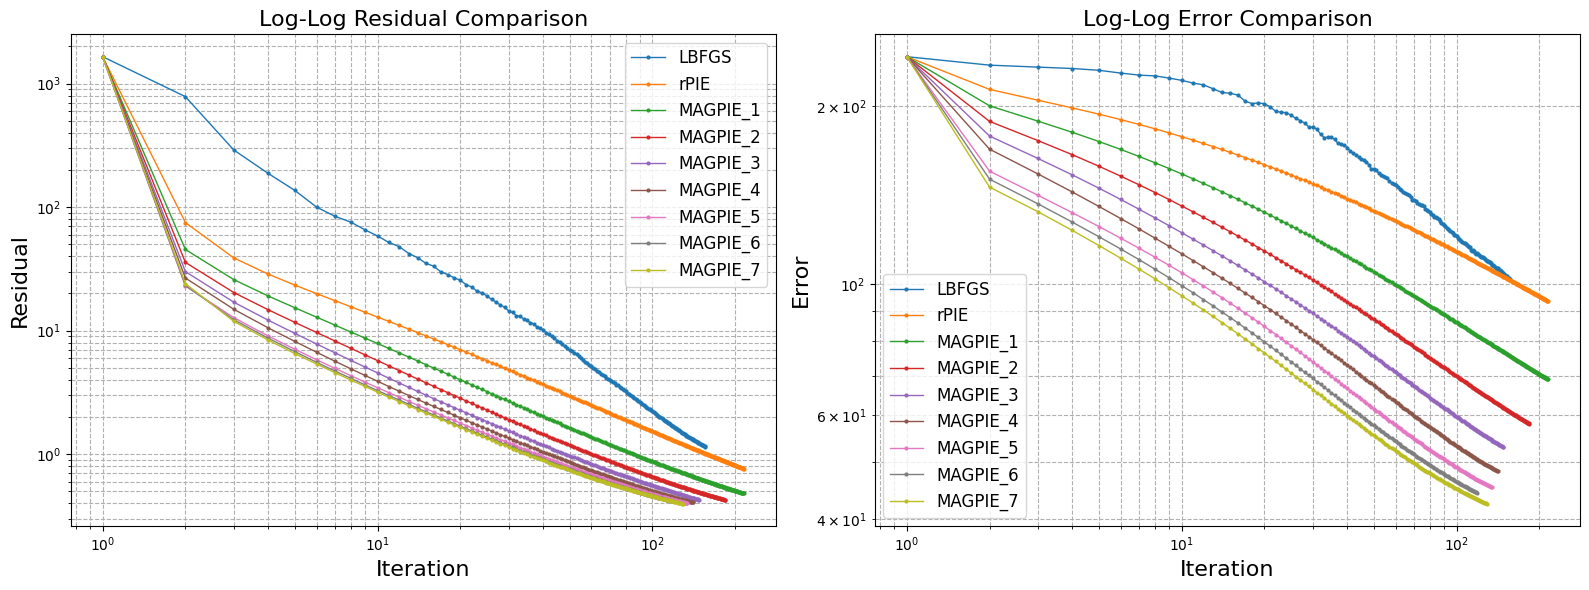

In [31]:
# Create a figure with 1 row and 2 columns of subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16,6))

# --- Left subplot (Residuals) ---
ax1.plot(np.arange(1, len(res_f_LBFGS) + 1), res_f_LBFGS,    label='LBFGS',   linestyle='-', marker='o', linewidth=1, markersize=2)
ax1.plot(np.arange(1, len(res_rPIE)     + 1), res_rPIE,      label='rPIE',     linestyle='-', marker='o', linewidth=1, markersize=2)
ax1.plot(np.arange(1, len(res_MAGPIE_1) + 1), res_MAGPIE_1,  label='MAGPIE_1', linestyle='-', marker='o', linewidth=1, markersize=2)
ax1.plot(np.arange(1, len(res_MAGPIE_2) + 1), res_MAGPIE_2,  label='MAGPIE_2', linestyle='-', marker='o', linewidth=1, markersize=2)
ax1.plot(np.arange(1, len(res_MAGPIE_3) + 1), res_MAGPIE_3,  label='MAGPIE_3', linestyle='-', marker='o', linewidth=1, markersize=2)
ax1.plot(np.arange(1, len(res_MAGPIE_4) + 1), res_MAGPIE_4,  label='MAGPIE_4', linestyle='-', marker='o', linewidth=1, markersize=2)
ax1.plot(np.arange(1, len(res_MAGPIE_5) + 1), res_MAGPIE_5,  label='MAGPIE_5', linestyle='-', marker='o', linewidth=1, markersize=2)
ax1.plot(np.arange(1, len(res_MAGPIE_6) + 1), res_MAGPIE_6,  label='MAGPIE_6', linestyle='-', marker='o', linewidth=1, markersize=2)
ax1.plot(np.arange(1, len(res_MAGPIE_7) + 1), res_MAGPIE_7,  label='MAGPIE_7', linestyle='-', marker='o', linewidth=1, markersize=2)
ax1.set_xlabel('Iteration', fontsize=16)
ax1.set_ylabel('Residual', fontsize=16)
ax1.set_title('Log-Log Residual Comparison', fontsize=16)
ax1.set_yscale('log')
ax1.set_xscale('log')
ax1.legend(fontsize=12)
ax1.grid(True, which="both", ls="--")

# --- Right subplot (Errors) ---
ax2.plot(np.arange(1, len(errors_LBFGS) + 1), errors_LBFGS,    label='LBFGS',   linestyle='-', marker='o', linewidth=1, markersize=2)
ax2.plot(np.arange(1, len(errors_rPIE)     + 1), errors_rPIE,      label='rPIE',     linestyle='-', marker='o', linewidth=1, markersize=2)
ax2.plot(np.arange(1, len(errors_MAGPIE_1) + 1), errors_MAGPIE_1,  label='MAGPIE_1', linestyle='-', marker='o', linewidth=1, markersize=2)
ax2.plot(np.arange(1, len(errors_MAGPIE_2) + 1), errors_MAGPIE_2,  label='MAGPIE_2', linestyle='-', marker='o', linewidth=1, markersize=2)
ax2.plot(np.arange(1, len(errors_MAGPIE_3) + 1), errors_MAGPIE_3,  label='MAGPIE_3', linestyle='-', marker='o', linewidth=1, markersize=2)
ax2.plot(np.arange(1, len(errors_MAGPIE_4) + 1), errors_MAGPIE_4,  label='MAGPIE_4', linestyle='-', marker='o', linewidth=1, markersize=2)
ax2.plot(np.arange(1, len(errors_MAGPIE_5) + 1), errors_MAGPIE_5,  label='MAGPIE_5', linestyle='-', marker='o', linewidth=1, markersize=2)
ax2.plot(np.arange(1, len(errors_MAGPIE_6) + 1), errors_MAGPIE_6,  label='MAGPIE_6', linestyle='-', marker='o', linewidth=1, markersize=2)
ax2.plot(np.arange(1, len(errors_MAGPIE_7) + 1), errors_MAGPIE_7,  label='MAGPIE_7', linestyle='-', marker='o', linewidth=1, markersize=2)
ax2.set_xlabel('Iteration', fontsize=16)
ax2.set_ylabel('Error', fontsize=16)
ax2.set_title('Log-Log Error Comparison', fontsize=16)
ax2.set_yscale('log')
ax2.set_xscale('log')
ax2.legend(fontsize=12)
ax2.grid(True, which="both", ls="--")

plt.tight_layout()
#plt.savefig('metric_1.png', dpi=120, bbox_inches='tight')
plt.show()


/var/folders/26/rw2jcprn5qv45z71fxbk4t2w0000gn/T/ipykernel_79930/1316764573.py:7: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  intensity_ground_truth = np.abs(ground_truth)
/var/folders/26/rw2jcprn5qv45z71fxbk4t2w0000gn/T/ipykernel_79930/1316764573.py:15: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  intensity_LBFGS, phase_LBFGS = np.abs(LBFGS_image), np.angle(LBFGS_image)
/var/folders/26/rw2jcprn5qv45z71fxbk4t2w0000gn/T/ipykernel_79930/1316764573.py:16: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  intensity_rPIE, phase_rPIE = np.abs(rPIE_image), np.angle(rPIE_image)
/var/folders/26/rw2jcprn5qv45z71fxbk4t2w0000gn/T/ipykernel_79930/1316764573.py:17: DeprecationWarning: __array_wrap__ must accept context and return

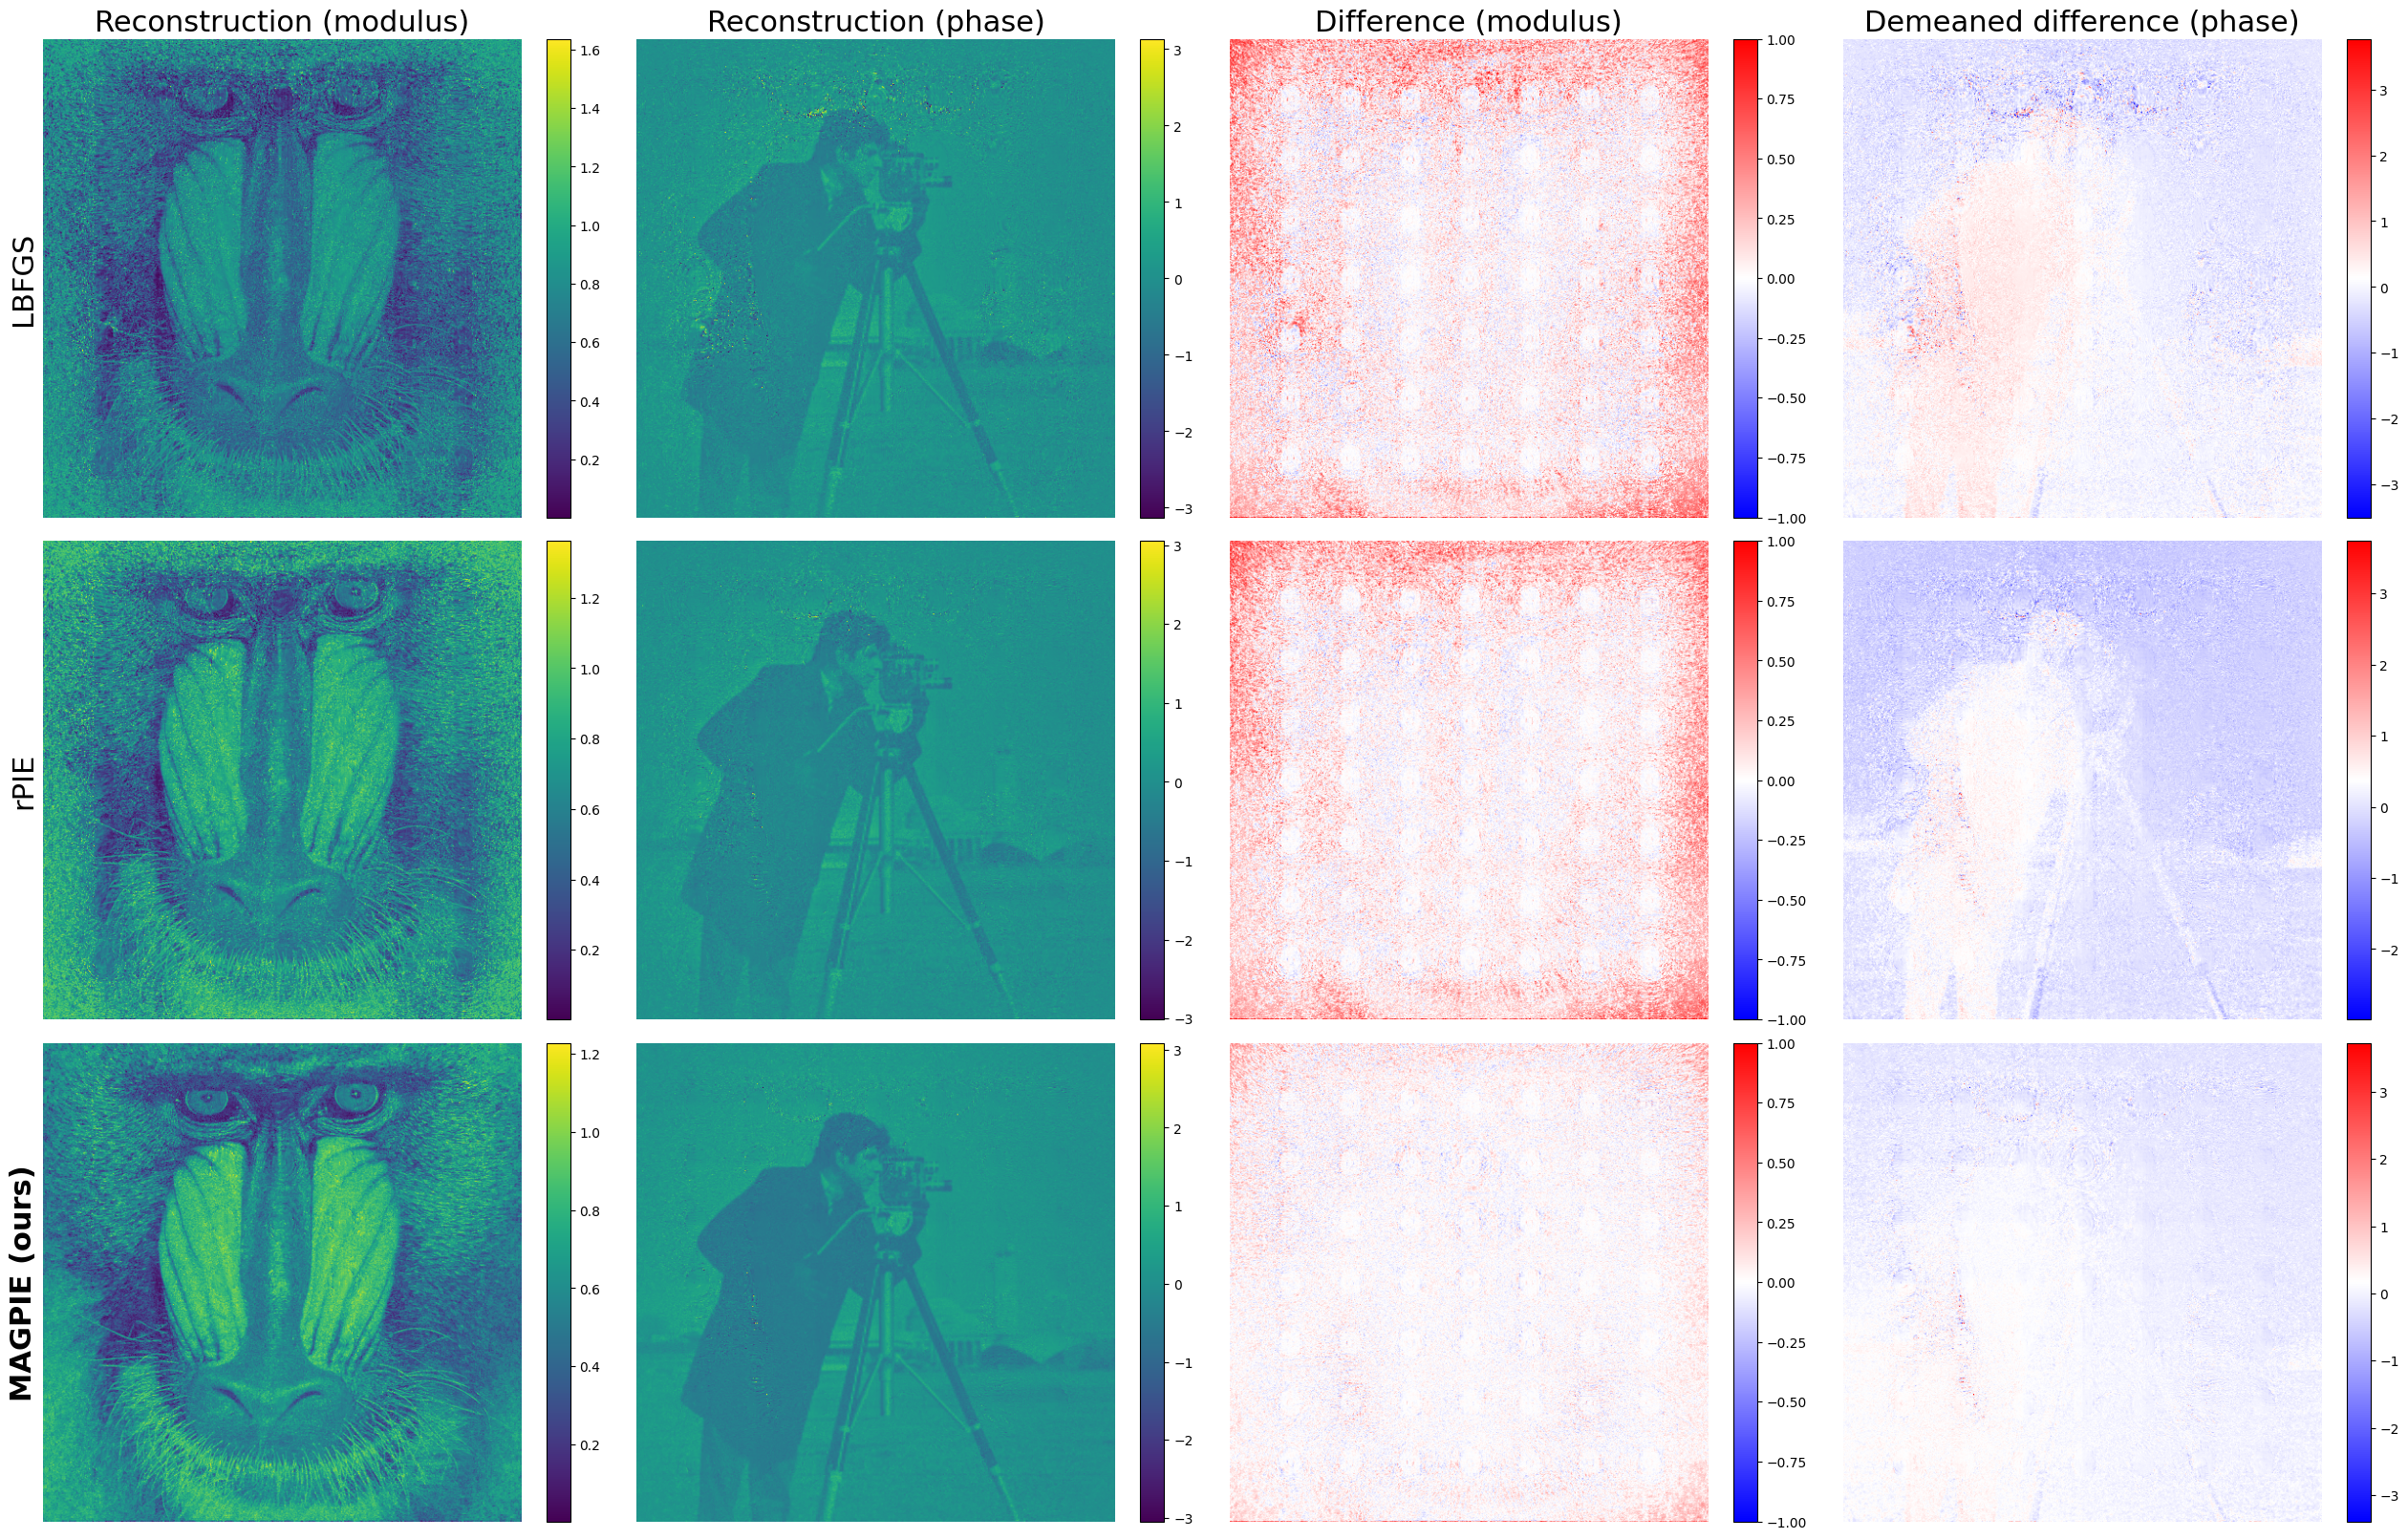

In [33]:
size = object_shape
rPIE_image = z_recon_rPIE
MAGPIE_image = z_recon_MAGPIE_7
LBFGS_image = zstar.view(np.complex128).reshape(object_shape)
ground_truth = ground_truth

intensity_ground_truth = np.abs(ground_truth)
phase_ground_truth = np.angle(ground_truth)

def calculate_difference(image, ground_truth):
    intensity_diff = np.abs(image) - intensity_ground_truth
    phase_diff = np.angle(image) - phase_ground_truth - np.mean(np.angle(image) - phase_ground_truth)
    return intensity_diff, phase_diff

intensity_LBFGS, phase_LBFGS = np.abs(LBFGS_image), np.angle(LBFGS_image)
intensity_rPIE, phase_rPIE = np.abs(rPIE_image), np.angle(rPIE_image)
intensity_MAGPIE, phase_MAGPIE = np.abs(MAGPIE_image), np.angle(MAGPIE_image)

# Calculate differences
intensity_diff_LBFGS, phase_diff_LBFGS = calculate_difference(LBFGS_image, ground_truth)
intensity_diff_rPIE, phase_diff_rPIE = calculate_difference(rPIE_image, ground_truth)
intensity_diff_MAGPIE, phase_diff_MAGPIE = calculate_difference(MAGPIE_image, ground_truth)

# Updated column titles and row labels
column_titles = [
    "Reconstruction (modulus)", 
    "Reconstruction (phase)", 
    "Difference (modulus)", 
    "Demeaned difference (phase)"
]
row_labels = ["LBFGS", "rPIE", "MAGPIE (ours)"]

# Prepare data for plotting: each tuple contains (intensity, phase, intensity_diff, phase_diff)
image_data = [
    (intensity_LBFGS, phase_LBFGS, intensity_diff_LBFGS, phase_diff_LBFGS),
    (intensity_rPIE, phase_rPIE, intensity_diff_rPIE, phase_diff_rPIE),
    (intensity_MAGPIE, phase_MAGPIE, intensity_diff_MAGPIE, phase_diff_MAGPIE),
]

# Create a new figure using subplots 
fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(25, 16), constrained_layout=True)

# Set column titles on the first row.
for j, title in enumerate(column_titles):
    axes[0, j].set_title(title, fontsize=22)

# Loop over each row of image data.
for i, (intensity, phase, intensity_diff, phase_diff) in enumerate(image_data):
    # Set the row label for the first column.
    if i == 2:
        axes[i, 0].set_ylabel(row_labels[i], fontsize=22, fontweight='bold')
    else:
        axes[i, 0].set_ylabel(row_labels[i], fontsize=22)

    # Remove spines and ticks for clarity.
    for j in range(4):
        ax = axes[i, j]
        for spine in ax.spines.values():
            spine.set_visible(False)
        ax.set_xticks([])
        ax.set_yticks([])

    # Plot the intensity image.
    im0 = axes[i, 0].imshow(intensity, cmap='viridis')
    fig.colorbar(im0, ax=axes[i, 0])

    # Plot the phase image.
    im1 = axes[i, 1].imshow(phase, cmap='viridis')
    fig.colorbar(im1, ax=axes[i, 1])
    
    # Plot the intensity difference image with symmetric scaling.
    max_intensity_diff = np.max(np.abs(intensity_diff))
    im2 = axes[i, 2].imshow(intensity_diff, cmap='bwr', vmin=-1, vmax=1)
    fig.colorbar(im2, ax=axes[i, 2])

    # Plot the phase difference image with symmetric scaling.
    max_phase_diff = np.max(np.abs(phase_diff))
    im3 = axes[i, 3].imshow(phase_diff, cmap='bwr')
    fig.colorbar(im3, ax=axes[i, 3])

#plt.savefig('reconstruction.png', dpi=60, bbox_inches='tight')
plt.show()